# 🫀 Final Project: Predicting Heart Disease
### Ibn Sina Training Academy — Data Analysis using Python
---
**Goal:** Build a machine learning model that predicts the presence of heart disease in a patient based on their clinical data.

## Step 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---
## Step 2: Load & Understand the Data

In [5]:
import os
os.chdir(r'D:\heart_disease_project')


In [6]:
# Column names based on UCI Heart Disease dataset documentation
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Load Cleveland dataset (replace '?' missing values with NaN)
df = pd.read_csv(
    'processed.cleveland.data',
    names=column_names,
    na_values='?'
)

print(f'Dataset shape: {df.shape}')
df.head(10)

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [7]:
# Column descriptions
descriptions = {
    'age'     : 'Age in years',
    'sex'     : '1 = Male, 0 = Female',
    'cp'      : 'Chest Pain Type (1-4)',
    'trestbps': 'Resting Blood Pressure (mm Hg)',
    'chol'    : 'Serum Cholesterol (mg/dl)',
    'fbs'     : 'Fasting Blood Sugar > 120 mg/dl (1=True)',
    'restecg' : 'Resting ECG Results (0-2)',
    'thalach' : 'Maximum Heart Rate Achieved',
    'exang'   : 'Exercise Induced Angina (1=Yes)',
    'oldpeak' : 'ST Depression Induced by Exercise',
    'slope'   : 'Slope of Peak Exercise ST Segment',
    'ca'      : 'Number of Major Vessels (0-3)',
    'thal'    : 'Thalassemia (3=Normal, 6=Fixed Defect, 7=Reversible)',
    'target'  : '0 = No Disease, 1-4 = Disease Present'
}

desc_df = pd.DataFrame(list(descriptions.items()), columns=['Feature', 'Description'])
print(desc_df.to_string(index=False))

 Feature                                          Description
     age                                         Age in years
     sex                                 1 = Male, 0 = Female
      cp                                Chest Pain Type (1-4)
trestbps                       Resting Blood Pressure (mm Hg)
    chol                            Serum Cholesterol (mg/dl)
     fbs             Fasting Blood Sugar > 120 mg/dl (1=True)
 restecg                            Resting ECG Results (0-2)
 thalach                          Maximum Heart Rate Achieved
   exang                      Exercise Induced Angina (1=Yes)
 oldpeak                    ST Depression Induced by Exercise
   slope                    Slope of Peak Exercise ST Segment
      ca                        Number of Major Vessels (0-3)
    thal Thalassemia (3=Normal, 6=Fixed Defect, 7=Reversible)
  target                0 = No Disease, 1-4 = Disease Present


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


---
## Step 3: Data Cleaning & Preparation

In [10]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [11]:
# Drop rows with missing values (only 6 rows affected)
df.dropna(inplace=True)
print(f'Shape after dropping NaN: {df.shape}')

# Convert target to binary: 0 = No Disease, 1 = Disease
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print('\nTarget distribution:')
print(df['target'].value_counts())
print(f'\nNo Disease (0): {(df["target"]==0).sum()} patients')
print(f'Disease    (1): {(df["target"]==1).sum()} patients')

Shape after dropping NaN: (297, 14)

Target distribution:
target
0    160
1    137
Name: count, dtype: int64

No Disease (0): 160 patients
Disease    (1): 137 patients


---
## Step 4: Exploratory Data Analysis (EDA)

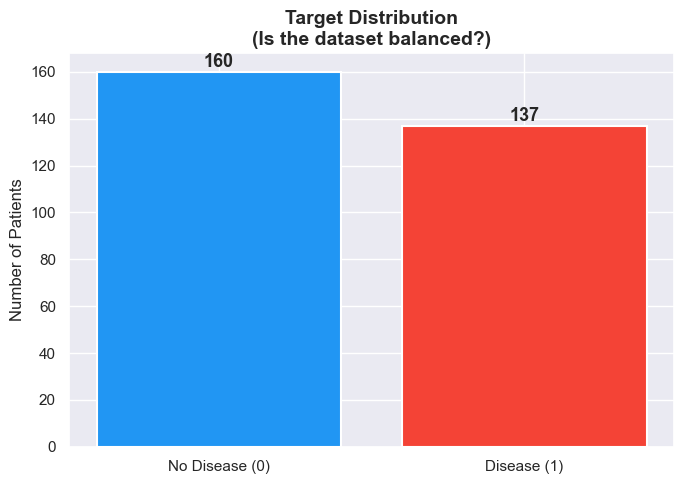

In [12]:
# --- 4.1 Target Distribution ---
fig, ax = plt.subplots(figsize=(7, 5))
counts = df['target'].value_counts()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values,
              color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', fontsize=13, fontweight='bold')

ax.set_title('Target Distribution\n(Is the dataset balanced?)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Patients')
plt.tight_layout()
plt.show()

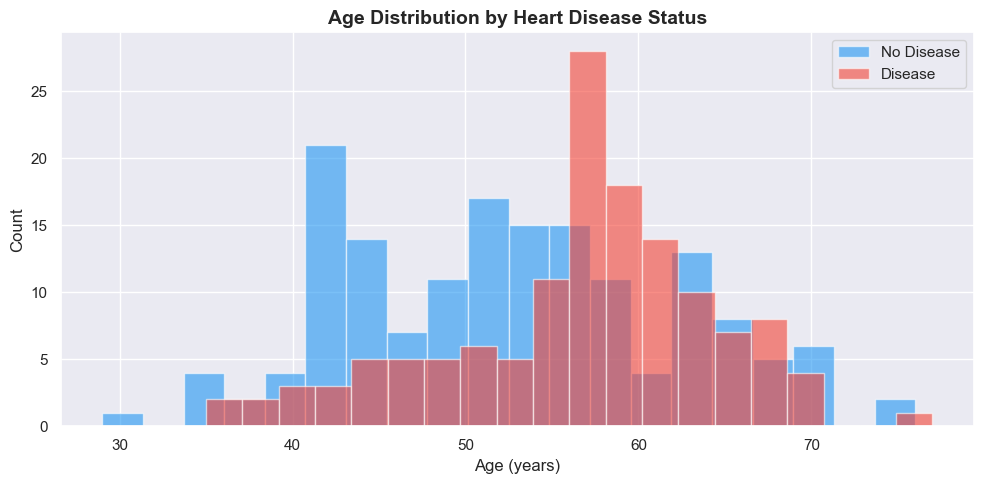

Average age — No Disease: 52.6 yrs
Average age — Disease:    56.8 yrs


In [14]:
# --- 4.2 Age Distribution by Disease Status ---
fig, ax = plt.subplots(figsize=(10, 5))
df[df['target'] == 0]['age'].plot(kind='hist', bins=20, alpha=0.6,
                                   color='#2196F3', label='No Disease', ax=ax)
df[df['target'] == 1]['age'].plot(kind='hist', bins=20, alpha=0.6,
                                   color='#F44336', label='Disease', ax=ax)
ax.set_title('Age Distribution by Heart Disease Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Average age — No Disease: {df[df["target"]==0]["age"].mean():.1f} yrs')
print(f'Average age — Disease:    {df[df["target"]==1]["age"].mean():.1f} yrs')

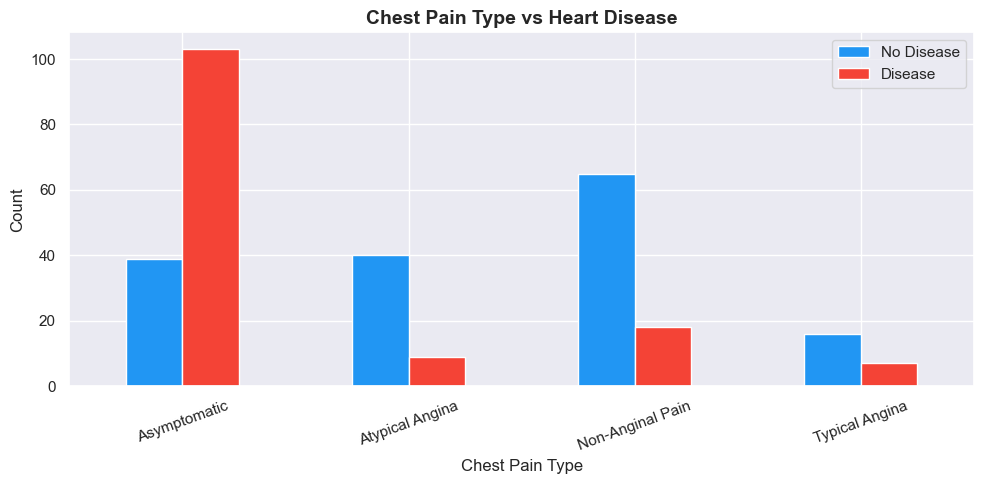

In [15]:
# --- 4.3 Chest Pain Type vs Target ---
cp_labels = {1: 'Typical Angina', 2: 'Atypical Angina',
             3: 'Non-Anginal Pain', 4: 'Asymptomatic'}
df['cp_label'] = df['cp'].map(cp_labels)

fig, ax = plt.subplots(figsize=(10, 5))
ct = pd.crosstab(df['cp_label'], df['target'])
ct.columns = ['No Disease', 'Disease']
ct.plot(kind='bar', ax=ax, color=['#2196F3', '#F44336'],
        edgecolor='white', linewidth=1)
ax.set_title('Chest Pain Type vs Heart Disease', fontsize=14, fontweight='bold')
ax.set_xlabel('Chest Pain Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

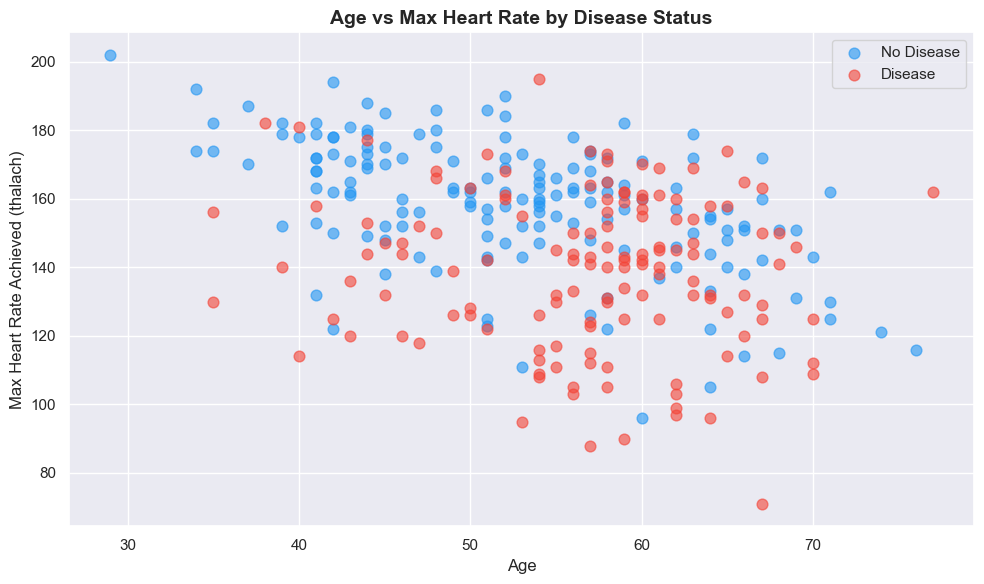

In [16]:
# --- 4.4 Max Heart Rate (thalach) vs Age, colored by Target ---
fig, ax = plt.subplots(figsize=(10, 6))
no_disease = df[df['target'] == 0]
disease    = df[df['target'] == 1]

ax.scatter(no_disease['age'], no_disease['thalach'],
           alpha=0.6, color='#2196F3', label='No Disease', s=60)
ax.scatter(disease['age'], disease['thalach'],
           alpha=0.6, color='#F44336', label='Disease', s=60)

ax.set_title('Age vs Max Heart Rate by Disease Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Max Heart Rate Achieved (thalach)')
ax.legend()
plt.tight_layout()
plt.show()

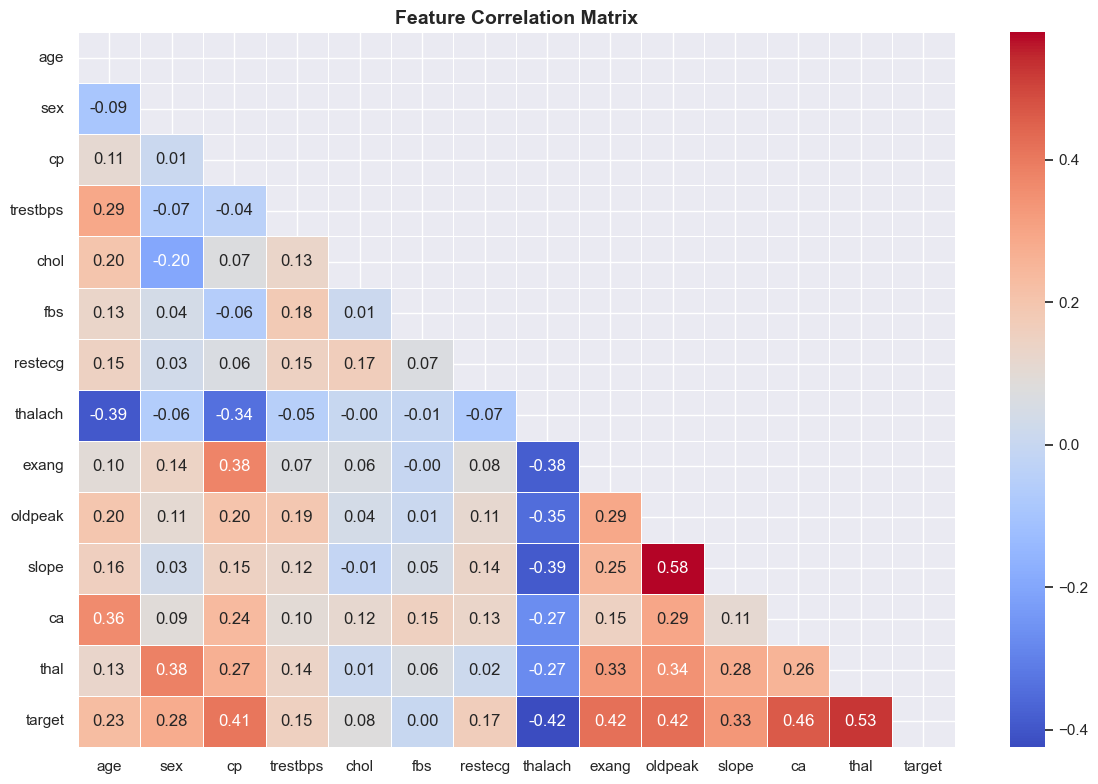

In [17]:
# --- 4.5 Correlation Heatmap ---
df_corr = df.drop(columns=['cp_label'])
fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 5: Modeling
### 5.1 Prepare Features & Split Data

In [18]:
# Drop helper column
df.drop(columns=['cp_label'], inplace=True)

X = df.drop(columns=['target'])
y = df['target']

# Train / Test split  (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 237
Testing  samples : 60


In [19]:
# Scale numerical features
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Features scaled successfully!')

✅ Features scaled successfully!


### 5.2 Model 1 — Logistic Regression

In [20]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_preds    = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_preds)

print(f'📊 Logistic Regression Accuracy: {lr_accuracy:.2%}')
print('\nClassification Report:')
print(classification_report(y_test, lr_preds,
      target_names=['No Disease', 'Disease']))

📊 Logistic Regression Accuracy: 83.33%

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



### 5.3 Model 2 — Random Forest Classifier

In [21]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_preds    = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_preds)

print(f'📊 Random Forest Accuracy: {rf_accuracy:.2%}')
print('\nClassification Report:')
print(classification_report(y_test, rf_preds,
      target_names=['No Disease', 'Disease']))

📊 Random Forest Accuracy: 86.67%

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.85      0.91      0.88        32
     Disease       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



---
## Step 6: Evaluation

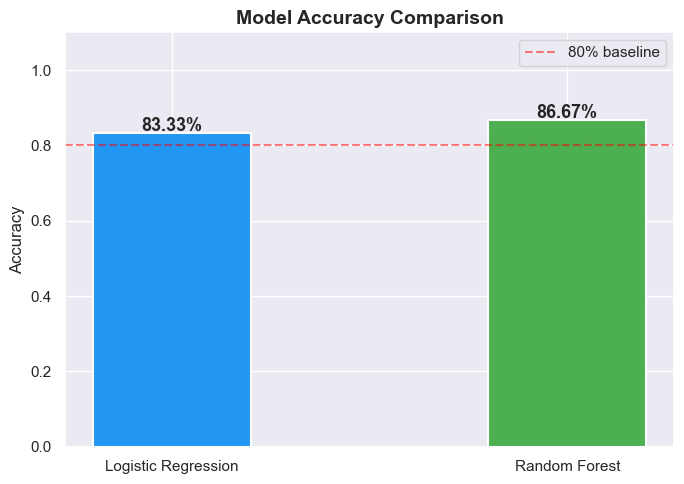

In [22]:
# --- 6.1 Model Accuracy Comparison ---
fig, ax = plt.subplots(figsize=(7, 5))
models = ['Logistic Regression', 'Random Forest']
scores = [lr_accuracy, rf_accuracy]
colors = ['#2196F3', '#4CAF50']

bars = ax.bar(models, scores, color=colors, edgecolor='white', linewidth=1.5, width=0.4)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{score:.2%}', ha='center', fontsize=13, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80% baseline')
ax.legend()
plt.tight_layout()
plt.show()

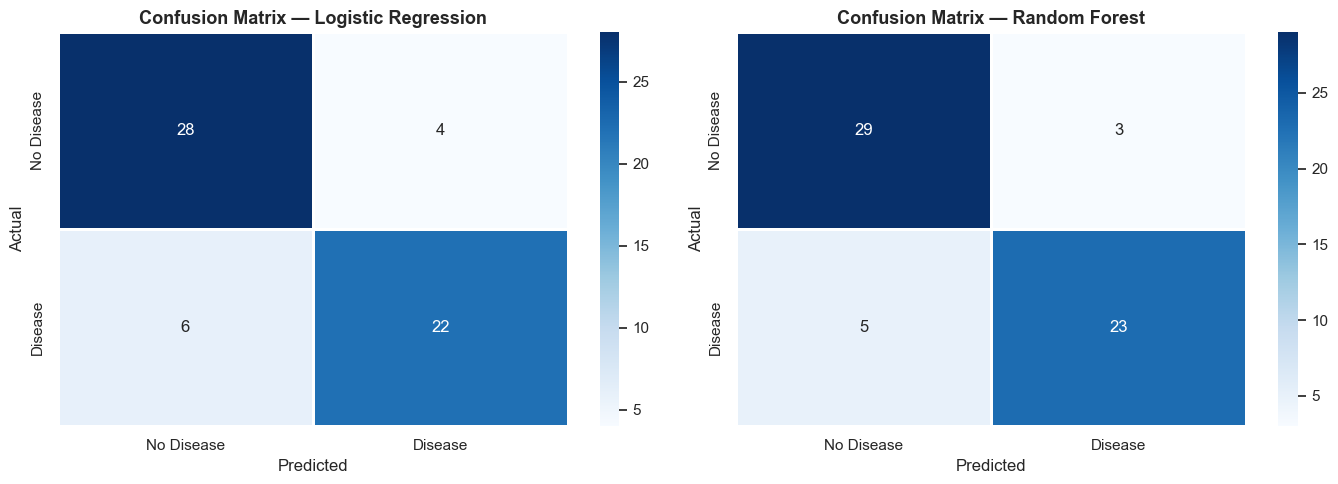

In [23]:
# --- 6.2 Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=1, linecolor='white')
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

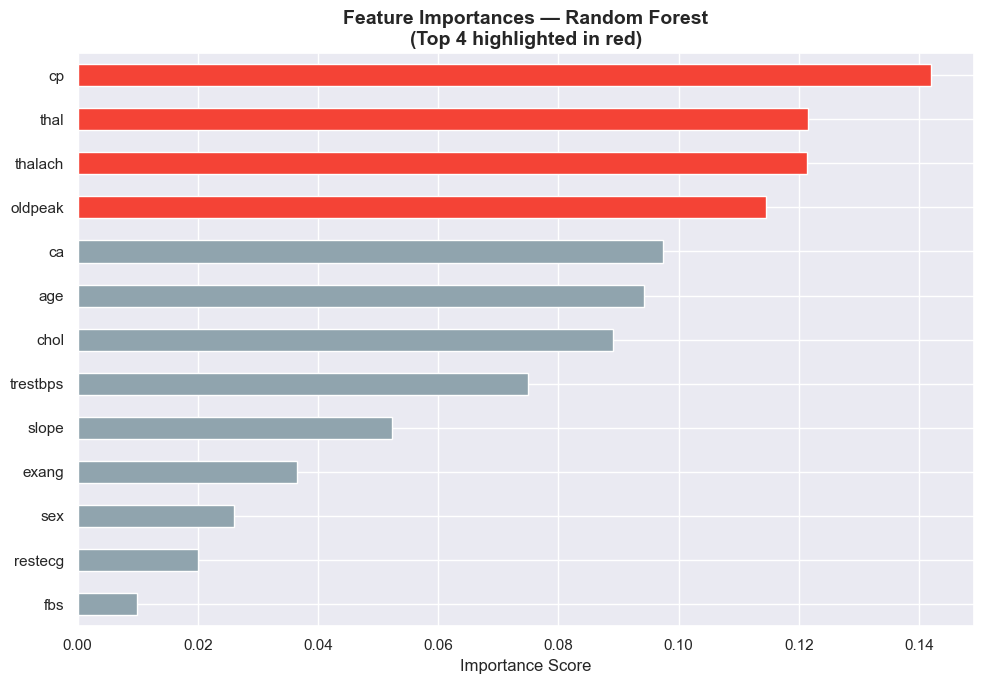


Top 4 most important features:
cp         0.142050
thal       0.121571
thalach    0.121296
oldpeak    0.114585


In [24]:
# --- 6.3 Feature Importance (Random Forest) ---
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#F44336' if i >= len(importances)-4 else '#90A4AE'
              for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('Feature Importances — Random Forest\n(Top 4 highlighted in red)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 4 most important features:')
print(importances.sort_values(ascending=False).head(4).to_string())

---
## Step 7: Conclusion & Summary

In [25]:
print('=' * 55)
print('         FINAL PROJECT — SUMMARY RESULTS')
print('=' * 55)
print(f'  Dataset          : Cleveland Heart Disease (UCI)')
print(f'  Total patients   : {df.shape[0]}')
print(f'  Features used    : {X.shape[1]}')
print(f'  Train / Test     : 80% / 20%')
print('-' * 55)
print(f'  Logistic Regression Accuracy : {lr_accuracy:.2%}')
print(f'  Random Forest Accuracy       : {rf_accuracy:.2%}')
print('-' * 55)
best_model = 'Random Forest' if rf_accuracy > lr_accuracy else 'Logistic Regression'
best_acc   = max(lr_accuracy, rf_accuracy)
print(f'  ✅ Best Model: {best_model} ({best_acc:.2%})')
print('=' * 55)
print()
print('Top Predictors of Heart Disease:')
for i, (feat, score) in enumerate(
    importances.sort_values(ascending=False).head(4).items(), 1
):
    print(f'  {i}. {feat:12s}  →  {score:.4f}')
print()
print('Recommendation: This model can assist medical professionals')
print('in early detection and risk stratification of heart disease.')

         FINAL PROJECT — SUMMARY RESULTS
  Dataset          : Cleveland Heart Disease (UCI)
  Total patients   : 297
  Features used    : 13
  Train / Test     : 80% / 20%
-------------------------------------------------------
  Logistic Regression Accuracy : 83.33%
  Random Forest Accuracy       : 86.67%
-------------------------------------------------------
  ✅ Best Model: Random Forest (86.67%)

Top Predictors of Heart Disease:
  1. cp            →  0.1420
  2. thal          →  0.1216
  3. thalach       →  0.1213
  4. oldpeak       →  0.1146

Recommendation: This model can assist medical professionals
in early detection and risk stratification of heart disease.
